## 6 — Modeling Improvement and Tuning (Sprint 4)

### Sprint objective
Improve the Sprint 3 MVP modeling results by adding **careful hyperparameter tuning**, stronger **stability/overfitting diagnostics**, and **thesis-ready result figures**.

This notebook is **self-contained** and compares:
- **Base dataset**: `datasets/model_ready_base.csv`
- **Spatial dataset**: `datasets/model_ready_spatial.csv`

Models:
1. Linear Regression baseline
2. Random Forest
3. XGBoost

Key thesis constraints:
- Leakage-aware feature selection (no target/near-target columns, no target lags/spillovers)
- Leakage-safe preprocessing inside sklearn pipelines
- 5-fold CV (GroupKFold preferred if municipality column exists)
- Fold-level train vs validation metrics


## 2. Imports and reproducibility settings


In [128]:
from __future__ import annotations

import json
import re
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, KFold, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


In [129]:
# Optional: XGBoost import
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = repr(e)

print("XGBoost available:", XGBOOST_AVAILABLE)
if not XGBOOST_AVAILABLE:
    print("XGBoost import error:", XGBOOST_IMPORT_ERROR)
    print("\nIf this is a libomp/OpenMP issue on macOS, fix that first (see Sprint notes), then restart kernel.")


XGBoost available: True


In [130]:
# Package versions (reproducibility)
try:
    from importlib.metadata import version
except Exception:
    from importlib_metadata import version  # type: ignore

pkgs = ["numpy", "pandas", "scikit-learn", "xgboost"]
versions = {}
for p in pkgs:
    try:
        versions[p] = version(p)
    except Exception:
        versions[p] = None
print(json.dumps(versions, indent=2))


{
  "numpy": "2.4.4",
  "pandas": "2.3.3",
  "scikit-learn": "1.8.0",
  "xgboost": "3.2.0"
}


## 3. Load base and spatial datasets


In [131]:
DATA_DIR = Path("datasets")
OUT_DIR = Path("outputs") / "modeling_improvement"
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# IMPORTANT: This notebook uses TRAIN split only for CV/tuning.
BASE_TRAIN_PATH = DATA_DIR / "model_ready_base_train.csv"
SPATIAL_TRAIN_PATH = DATA_DIR / "model_ready_spatial_train.csv"

BASE_TEST_PATH = DATA_DIR / "model_ready_base_test.csv"
SPATIAL_TEST_PATH = DATA_DIR / "model_ready_spatial_test.csv"

if not BASE_TRAIN_PATH.exists() or not SPATIAL_TRAIN_PATH.exists():
    raise FileNotFoundError(
        "Train/test split files not found. Run notebook 5 first to create: "
        "datasets/model_ready_*_{train,test}.csv"
    )

base_df = pd.read_csv(BASE_TRAIN_PATH, low_memory=False)
spatial_df = pd.read_csv(SPATIAL_TRAIN_PATH, low_memory=False)

print("base_df (TRAIN) shape:", base_df.shape)
print("spatial_df (TRAIN) shape:", spatial_df.shape)


base_df (TRAIN) shape: (11379, 105)
spatial_df (TRAIN) shape: (11379, 117)


## 4. Detect target, ID, grouping, and leakage columns


Target: log_crime_count
Group col: gm_naam

Target stats:
count    11379.000000
mean         3.135633
std          1.382220
min          0.000000
25%          2.197225
50%          3.135494
75%          4.077537
max          8.220134


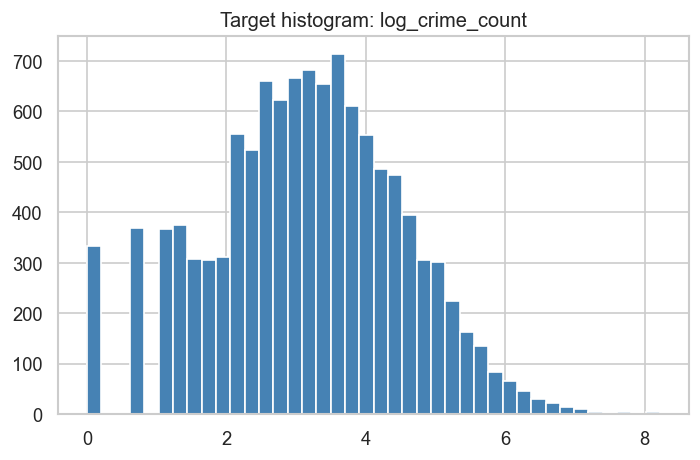

In [132]:
# Target / grouping variables (fixed by preprocessing pipeline)
TARGET_COL = "log_crime_count"
if TARGET_COL not in base_df.columns or TARGET_COL not in spatial_df.columns:
    raise KeyError(f"Expected '{TARGET_COL}' in both base and spatial datasets.")

# Municipality-grouped CV (fixed for this thesis)
GROUP_COL = "gm_naam"
if GROUP_COL not in base_df.columns:
    raise KeyError(f"Expected grouping column '{GROUP_COL}' in dataset.")

# Columns excluded from predictors (identifiers, labels, and non-feature context)
ID_COLS_BASE = [
    "gwb_code_10",
    "gwb_code_8",
    "gwb_code",
    "merge_key",
    "regio",
    "gm_naam",
    "ID",
    "Perioden",
    "SoortMisdrijf",
    "recs",
    "centroid_x",
    "centroid_y",
]
ID_COLS_SPATIAL = ID_COLS_BASE.copy()

# Raw/near-target columns that must not be used as predictors
RAW_TARGET_LIKE = {
    "crime_count",
    "crime_rate_per_1000",
    "population",
    "population_zero",
    "GeregistreerdeMisdrijven_1",
    "a_inw",
}

# Leakage patterns: ban target-derived lags/spillovers (keep exogenous queen_lag_* features)
LEAKAGE_PATTERNS = [
    r"spillover_spec",
    r"spillover_target",
    r"target_lag",
    r"lag_y",
    r"spillover_lag",
    r"lag_.*crime",
    r"crime.*lag",
]
LEAKAGE_REGEX = re.compile("|".join(LEAKAGE_PATTERNS), flags=re.IGNORECASE)

print("Target:", TARGET_COL)
print("Group col:", GROUP_COL)

print("\nTarget stats:")
print(base_df[TARGET_COL].describe().to_string())
plt.figure(figsize=(6,4))
plt.hist(base_df[TARGET_COL].dropna(), bins=40, color='steelblue', edgecolor='white')
plt.title(f"Target histogram: {TARGET_COL}")
plt.tight_layout()
plt.savefig(FIG_DIR / f"target_hist_{TARGET_COL}.png")
plt.show()


## 5. Define feature matrices


In [133]:
def select_numeric_predictors(
    df: pd.DataFrame,
    target: str,
    id_cols: List[str],
) -> Tuple[pd.DataFrame, pd.Series, Dict[str, Any]]:
    df = df.copy()

    # Exclude ID/context columns, target, raw target-like columns, and any columns that match leakage patterns
    leak = [c for c in df.columns if LEAKAGE_REGEX.search(c)]
    exclude = set(id_cols) | set(leak) | set(RAW_TARGET_LIKE) | {target}

    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    feature_cols = [c for c in num_cols if c not in exclude]

    X = df[feature_cols].copy()
    y = df[target].copy()

    # Leakage assertions
    assert target not in X.columns
    assert not any(LEAKAGE_REGEX.search(c) for c in X.columns)
    assert not any(c.lower().startswith("y_") for c in X.columns)

    # Extra guard: remove any feature that exactly duplicates y
    dup_like = []
    for c in feature_cols:
        try:
            if y.equals(df[c]):
                dup_like.append(c)
        except Exception:
            pass
    if dup_like:
        raise ValueError(f"Leakage detected: feature(s) exactly equal to target: {dup_like}")

    info = {
        "n_features": len(feature_cols),
        "spillover_cols": [c for c in feature_cols if c.startswith("queen_lag_")],
        "excluded_id_cols": id_cols,
        "excluded_leakage_cols": leak,
    }
    return X, y, info

X_base, y_base, info_base = select_numeric_predictors(base_df, TARGET_COL, ID_COLS_BASE)
X_spatial, y_spatial, info_spatial = select_numeric_predictors(spatial_df, TARGET_COL, ID_COLS_SPATIAL)

print("Base X shape:", X_base.shape)
print("Spatial X shape:", X_spatial.shape)
print("Spillover columns (spatial):", len(info_spatial["spillover_cols"]))
print(info_spatial["spillover_cols"][:40])


Base X shape: (11379, 83)
Spatial X shape: (11379, 95)
Spillover columns (spatial): 12
['queen_lag_sum_bev_dich', 'queen_lag_mean_bev_dich', 'queen_lag_sum_g_wozbag', 'queen_lag_mean_g_wozbag', 'queen_lag_sum_p_huurw', 'queen_lag_mean_p_huurw', 'queen_lag_sum_a_soz_wb', 'queen_lag_mean_a_soz_wb', 'queen_lag_sum_a_bedv', 'queen_lag_mean_a_bedv', 'queen_lag_sum_ste_oad', 'queen_lag_mean_ste_oad']


## 6. Define validation strategy


In [134]:
def make_cv(groups: Optional[pd.Series]):
    if groups is not None:
        return GroupKFold(n_splits=5), f"GroupKFold(5) on '{groups.name}'"
    print('WARNING: No group column found; using KFold instead of GroupKFold.')
    return KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), 'KFold(5, shuffle=True, random_state=42)'


def fold_diagnostics(cv, X, y, groups):
    sizes = []
    for i,(tr,va) in enumerate(cv.split(X,y,groups)):
        sizes.append((len(tr),len(va)))
        if groups is not None:
            ov = set(groups.iloc[tr].astype(str)).intersection(set(groups.iloc[va].astype(str)))
            if ov:
                raise ValueError('Group overlap detected')
    return sizes

groups_base = base_df[GROUP_COL] if GROUP_COL and GROUP_COL in base_df.columns else None
groups_spatial = spatial_df[GROUP_COL] if GROUP_COL and GROUP_COL in spatial_df.columns else None

cv_base, cv_desc_base = make_cv(groups_base)
cv_spatial, cv_desc_spatial = make_cv(groups_spatial)

print('Base CV:', cv_desc_base)
print('Fold sizes:', fold_diagnostics(cv_base, X_base, y_base, groups_base))

print('\nSpatial CV:', cv_desc_spatial)
print('Fold sizes:', fold_diagnostics(cv_spatial, X_spatial, y_spatial, groups_spatial))


Base CV: GroupKFold(5) on 'gm_naam'
Fold sizes: [(9102, 2277), (9104, 2275), (9103, 2276), (9103, 2276), (9104, 2275)]

Spatial CV: GroupKFold(5) on 'gm_naam'
Fold sizes: [(9102, 2277), (9104, 2275), (9103, 2276), (9103, 2276), (9104, 2275)]


## Helper functions for fold-by-fold evaluation


In [135]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def eval_foldwise(model: Pipeline, X: pd.DataFrame, y: pd.Series, cv, groups: Optional[pd.Series], tag: Dict[str,str], context: pd.DataFrame):
    oof = np.full(len(y), np.nan)
    rows = []

    for fold,(tr,va) in enumerate(cv.split(X,y,groups)):
        m = Pipeline(steps=model.steps)
        m.fit(X.iloc[tr], y.iloc[tr])

        p_tr = m.predict(X.iloc[tr])
        p_va = m.predict(X.iloc[va])
        oof[va] = p_va

        rows.append({
            **tag,
            'fold': fold,
            'n_train': len(tr),
            'n_val': len(va),
            'rmse_train': rmse(y.iloc[tr], p_tr),
            'rmse_val': rmse(y.iloc[va], p_va),
            'mae_train': float(mean_absolute_error(y.iloc[tr], p_tr)),
            'mae_val': float(mean_absolute_error(y.iloc[va], p_va)),
            'r2_train': float(r2_score(y.iloc[tr], p_tr)),
            'r2_val': float(r2_score(y.iloc[va], p_va)),
        })

    fold_df = pd.DataFrame(rows)

    oof_df = context.copy()
    oof_df['dataset_type'] = tag['dataset_type']
    oof_df['model'] = tag['model']
    oof_df['tuning_status'] = tag['tuning_status']
    oof_df['y_true'] = y.values
    oof_df['y_pred_oof'] = oof
    oof_df['residual'] = oof_df['y_true'] - oof_df['y_pred_oof']
    oof_df['abs_error'] = oof_df['residual'].abs()

    if np.isnan(oof).any():
        raise RuntimeError('OOF contains NaN')

    return fold_df, oof_df


def summarize_models(fold_metrics: pd.DataFrame) -> pd.DataFrame:
    g = fold_metrics.groupby(['model','dataset_type','tuning_status'])
    out = g.agg(
        mean_train_RMSE=('rmse_train','mean'),
        mean_val_RMSE=('rmse_val','mean'),
        std_val_RMSE=('rmse_val','std'),
        mean_val_MAE=('mae_val','mean'),
        std_val_MAE=('mae_val','std'),
        mean_val_R2=('r2_val','mean'),
        std_val_R2=('r2_val','std'),
    ).reset_index()
    out['overfit_gap_RMSE'] = out['mean_val_RMSE'] - out['mean_train_RMSE']
    return out.sort_values(['dataset_type','mean_val_RMSE'])


## 7. Recreate MVP baseline performance


In [136]:
def pipe_ols() -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])


def pipe_rf_mvp() -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ])


def pipe_xgb_mvp() -> Pipeline:
    if not XGBOOST_AVAILABLE:
        raise ImportError(f"XGBoost unavailable: {XGBOOST_IMPORT_ERROR}")
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            xgb.XGBRegressor(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_lambda=1.0,
                objective="reg:squarederror",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ])

# MVP (train split only): untuned baselines via grouped CV
KEEP_CTX = [c for c in ["gwb_code_10", "gm_naam", "population", "crime_count"] if c in base_df.columns]
ctx_base = base_df[KEEP_CTX].copy() if KEEP_CTX else pd.DataFrame(index=base_df.index)
ctx_spatial = spatial_df[KEEP_CTX].copy() if KEEP_CTX else pd.DataFrame(index=spatial_df.index)

fold_tables = []

for dataset_type, (X, y, cv, groups, ctx) in {
    "base": (X_base, y_base, cv_base, groups_base, ctx_base),
    "spatial": (X_spatial, y_spatial, cv_spatial, groups_spatial, ctx_spatial),
}.items():
    f, _ = eval_foldwise(pipe_ols(), X, y, cv, groups, {"model": "OLS", "dataset_type": dataset_type, "tuning_status": "baseline"}, ctx)
    fold_tables.append(f)

    f, _ = eval_foldwise(pipe_rf_mvp(), X, y, cv, groups, {"model": "RF", "dataset_type": dataset_type, "tuning_status": "mvp"}, ctx)
    fold_tables.append(f)

    if XGBOOST_AVAILABLE:
        f, _ = eval_foldwise(pipe_xgb_mvp(), X, y, cv, groups, {"model": "XGB", "dataset_type": dataset_type, "tuning_status": "mvp"}, ctx)
        fold_tables.append(f)

fold_metrics_mvp = pd.concat(fold_tables, ignore_index=True)
MVP_CV_PATH = OUT_DIR / "mvp_cv_fold_metrics.csv"
fold_metrics_mvp.to_csv(MVP_CV_PATH, index=False)

mvp_summary = summarize_models(fold_metrics_mvp)
print("Saved MVP fold metrics to:", MVP_CV_PATH)
print(mvp_summary.to_string(index=False))


Saved MVP fold metrics to: outputs/modeling_improvement/mvp_cv_fold_metrics.csv
model dataset_type tuning_status  mean_train_RMSE  mean_val_RMSE  std_val_RMSE  mean_val_MAE  std_val_MAE  mean_val_R2  std_val_R2  overfit_gap_RMSE
  XGB         base           mvp         0.241601       0.569946      0.014735      0.417857     0.007318     0.827875    0.005467          0.328345
   RF         base           mvp         0.244655       0.588680      0.017865      0.429808     0.011579     0.816376    0.007133          0.344026
  OLS         base      baseline         0.680836       0.712464      0.027662      0.528127     0.014205     0.731181    0.009644          0.031629
  XGB      spatial           mvp         0.226673       0.558157      0.014793      0.411757     0.008946     0.834859    0.007393          0.331484
   RF      spatial           mvp         0.237412       0.576619      0.015239      0.424944     0.010091     0.823755    0.007874          0.339207
  OLS      spatial      ba

## 8. Hyperparameter tuning setup

**Why RandomizedSearchCV?**

Random Forest and XGBoost contain multiple interacting hyperparameters. A full grid search would be computationally expensive, while randomized search allows broader coverage of plausible parameter values within the available thesis sprint time.

Tuning uses the **same cross-validation strategy** as model evaluation.

**Thesis reporting:** after defining the RF and XGB search spaces, this notebook exports a single overview table of the hyperparameter grids.
Primary tuning metric: **negative RMSE**.


## 9. Tune Random Forest


In [137]:
rf_param_grid = {
    'model__n_estimators': [300, 500, 800],
    'model__max_depth': [None, 10, 20, 40],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 5, 10],
    'model__max_features': ['sqrt', 'log2', 0.5, 0.8],
    'model__bootstrap': [True],
}

# Save a compact overview of the RF search space (for thesis reporting)
rf_space = (
    pd.DataFrame({
        "model": "RF",
        "hyperparameter": list(rf_param_grid.keys()),
        "values": [str(v) for v in rf_param_grid.values()],
    })
)


def tune_rf(X, y, cv, groups, dataset_tag: str):
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    ])

    model_dir = OUT_DIR / "models"
    model_dir.mkdir(parents=True, exist_ok=True)

    best_path = model_dir / f"rf_best_{dataset_tag}.joblib"
    res_path = OUT_DIR / f"tuning_results_rf_{dataset_tag}.csv"

    # Cache best estimator + results to avoid reruns
    if best_path.exists() and res_path.exists():
        import joblib
        best = joblib.load(best_path)
        res = pd.read_csv(res_path)
        print('Loaded cached RF best estimator:', best_path)
        print('Loaded cached RF tuning results:', res_path)
        return best, res

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=rf_param_grid,
        n_iter=30,
        scoring='neg_root_mean_squared_error',
        cv=cv,
        n_jobs=1,
        random_state=RANDOM_STATE,
        verbose=1,
        return_train_score=True,
    )

    search.fit(X, y, **({'groups': groups} if groups is not None else {}))
    res = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
    res.to_csv(res_path, index=False)

    import joblib
    joblib.dump(search.best_estimator_, best_path)

    print('Best RF params', dataset_tag, ':', search.best_params_)
    print('Best RF CV neg-RMSE', dataset_tag, ':', search.best_score_)
    print('Saved RF best estimator:', best_path)
    print('Saved RF tuning results:', res_path)

    return search.best_estimator_, res

rf_best_base, rf_res_base = tune_rf(X_base, y_base, cv_base, groups_base, 'base')
rf_best_spatial, rf_res_spatial = tune_rf(X_spatial, y_spatial, cv_spatial, groups_spatial, 'spatial')


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RF params base : {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None, 'model__bootstrap': True}
Best RF CV neg-RMSE base : -0.5821652084295599
Saved RF best estimator: outputs/modeling_improvement/models/rf_best_base.joblib
Saved RF tuning results: outputs/modeling_improvement/tuning_results_rf_base.csv
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RF params spatial : {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None, 'model__bootstrap': True}
Best RF CV neg-RMSE spatial : -0.5678283928285712
Saved RF best estimator: outputs/modeling_improvement/models/rf_best_spatial.joblib
Saved RF tuning results: outputs/modeling_improvement/tuning_results_rf_spatial.csv


In [138]:
# (Removed) Manual "latest run" notes.
# Authoritative tuning outputs are exported by this notebook:
# - outputs/modeling_improvement/tuning_results_rf_base.csv
# - outputs/modeling_improvement/tuning_results_rf_spatial.csv
# and cached best estimators under outputs/modeling_improvement/models/.


## 10. Tune XGBoost


In [140]:
if not XGBOOST_AVAILABLE:
    raise ImportError(f"XGBoost unavailable; cannot run XGB tuning. Error: {XGBOOST_IMPORT_ERROR}")

xgb_param_grid = {
    'model__n_estimators': [300, 500, 800, 1000],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__max_depth': [3, 4, 5, 6, 8],
    'model__min_child_weight': [1, 3, 5, 10],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__reg_alpha': [0, 0.01, 0.1, 1],
    'model__reg_lambda': [0.5, 1, 2, 5],
}

# Save a compact overview of the XGB search space (for thesis reporting)
xgb_space = (
    pd.DataFrame({
        "model": "XGB",
        "hyperparameter": list(xgb_param_grid.keys()),
        "values": [str(v) for v in xgb_param_grid.values()],
    })
)


def tune_xgb(X, y, cv, groups, dataset_tag: str):
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', xgb.XGBRegressor(
            objective='reg:squarederror',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

    model_dir = OUT_DIR / "models"
    model_dir.mkdir(parents=True, exist_ok=True)

    best_path = model_dir / f"xgb_best_{dataset_tag}.joblib"
    res_path = OUT_DIR / f"tuning_results_xgb_{dataset_tag}.csv"

    if best_path.exists() and res_path.exists():
        import joblib
        best = joblib.load(best_path)
        res = pd.read_csv(res_path)
        print('Loaded cached XGB best estimator:', best_path)
        print('Loaded cached XGB tuning results:', res_path)
        return best, res

    # NOTE: use single-process here to avoid joblib multiprocessing
    # unpickling errors on some Python/numpy setups (BrokenProcessPool / RankWarning).
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=xgb_param_grid,
        n_iter=40,
        scoring='neg_root_mean_squared_error',
        cv=cv,
        n_jobs=1,
        random_state=RANDOM_STATE,
        verbose=1,
        return_train_score=True,
    )

    search.fit(X, y, **({'groups': groups} if groups is not None else {}))
    res = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
    res.to_csv(res_path, index=False)

    import joblib
    joblib.dump(search.best_estimator_, best_path)

    print('Best XGB params', dataset_tag, ':', search.best_params_)
    print('Best XGB CV neg-RMSE', dataset_tag, ':', search.best_score_)
    print('Saved XGB best estimator:', best_path)
    print('Saved XGB tuning results:', res_path)

    return search.best_estimator_, res

xgb_best_base, xgb_res_base = tune_xgb(X_base, y_base, cv_base, groups_base, 'base')
xgb_best_spatial, xgb_res_spatial = tune_xgb(X_spatial, y_spatial, cv_spatial, groups_spatial, 'spatial')


Fitting 5 folds for each of 40 candidates, totalling 200 fits


Best XGB params base : {'model__subsample': 0.6, 'model__reg_lambda': 1, 'model__reg_alpha': 0.1, 'model__n_estimators': 1000, 'model__min_child_weight': 3, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.6}
Best XGB CV neg-RMSE base : -0.5641522299658094
Saved XGB best estimator: outputs/modeling_improvement/models/xgb_best_base.joblib
Saved XGB tuning results: outputs/modeling_improvement/tuning_results_xgb_base.csv
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best XGB params spatial : {'model__subsample': 0.6, 'model__reg_lambda': 1, 'model__reg_alpha': 0.1, 'model__n_estimators': 1000, 'model__min_child_weight': 3, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.6}
Best XGB CV neg-RMSE spatial : -0.5512512106091773
Saved XGB best estimator: outputs/modeling_improvement/models/xgb_best_spatial.joblib
Saved XGB tuning results: outputs/modeling_improvement/tuning_results_xgb_spatial.csv


In [141]:
# Export hyperparameter search-space overview (RF + XGB)
hp_overview = pd.concat([rf_space, xgb_space], ignore_index=True)
hp_overview.to_csv(OUT_DIR / "hyperparameter_search_space_overview.csv", index=False)
print("Saved hyperparameter search-space overview to:", OUT_DIR / "hyperparameter_search_space_overview.csv")
print(hp_overview.to_string(index=False))


Saved hyperparameter search-space overview to: outputs/modeling_improvement/hyperparameter_search_space_overview.csv
model           hyperparameter                     values
   RF      model__n_estimators            [300, 500, 800]
   RF         model__max_depth         [None, 10, 20, 40]
   RF model__min_samples_split                 [2, 5, 10]
   RF  model__min_samples_leaf              [1, 2, 5, 10]
   RF      model__max_features ['sqrt', 'log2', 0.5, 0.8]
   RF         model__bootstrap                     [True]
  XGB      model__n_estimators      [300, 500, 800, 1000]
  XGB     model__learning_rate    [0.01, 0.03, 0.05, 0.1]
  XGB         model__max_depth            [3, 4, 5, 6, 8]
  XGB  model__min_child_weight              [1, 3, 5, 10]
  XGB         model__subsample            [0.6, 0.8, 1.0]
  XGB  model__colsample_bytree            [0.6, 0.8, 1.0]
  XGB         model__reg_alpha          [0, 0.01, 0.1, 1]
  XGB        model__reg_lambda             [0.5, 1, 2, 5]


In [ ]:
# (Removed) Manual "latest run" notes.
# Authoritative tuning outputs are exported by this notebook:
# - outputs/modeling_improvement/tuning_results_xgb_base.csv
# - outputs/modeling_improvement/tuning_results_xgb_spatial.csv
# and cached best estimators under outputs/modeling_improvement/models/.


## 11–12. Compare untuned vs tuned models and base vs spatial


In [142]:
# CV comparison (train split only): baseline vs MVP vs tuned
# This section produces a compact table for thesis write-up.

CACHE_FINAL = OUT_DIR / "final_model_comparison.csv"
CACHE_FOLDLVL = OUT_DIR / "fold_level_metrics.csv"

if CACHE_FINAL.exists() and CACHE_FOLDLVL.exists():
    final_comparison = pd.read_csv(CACHE_FINAL)
    fold_level_metrics = pd.read_csv(CACHE_FOLDLVL)
    print("Loaded cached CV comparison:", CACHE_FINAL)
    print("Loaded cached fold-level metrics:", CACHE_FOLDLVL)
else:
    fold_tables = []

    for dataset_type, (X, y, cv, groups, ctx) in {
        "base": (X_base, y_base, cv_base, groups_base, ctx_base),
        "spatial": (X_spatial, y_spatial, cv_spatial, groups_spatial, ctx_spatial),
    }.items():
        # OLS baseline
        f, _ = eval_foldwise(pipe_ols(), X, y, cv, groups, {"model": "OLS", "dataset_type": dataset_type, "tuning_status": "baseline"}, ctx)
        fold_tables.append(f)

        # RF MVP + tuned
        f, _ = eval_foldwise(pipe_rf_mvp(), X, y, cv, groups, {"model": "RF", "dataset_type": dataset_type, "tuning_status": "mvp"}, ctx)
        fold_tables.append(f)

        rf_best = rf_best_spatial if dataset_type == "spatial" else rf_best_base
        f, _ = eval_foldwise(rf_best, X, y, cv, groups, {"model": "RF", "dataset_type": dataset_type, "tuning_status": "tuned"}, ctx)
        fold_tables.append(f)

        # XGB MVP + tuned
        if XGBOOST_AVAILABLE:
            f, _ = eval_foldwise(pipe_xgb_mvp(), X, y, cv, groups, {"model": "XGB", "dataset_type": dataset_type, "tuning_status": "mvp"}, ctx)
            fold_tables.append(f)

            xgb_best = xgb_best_spatial if dataset_type == "spatial" else xgb_best_base
            f, _ = eval_foldwise(xgb_best, X, y, cv, groups, {"model": "XGB", "dataset_type": dataset_type, "tuning_status": "tuned"}, ctx)
            fold_tables.append(f)

    fold_level_metrics = pd.concat(fold_tables, ignore_index=True)
    final_comparison = summarize_models(fold_level_metrics)

    final_comparison.to_csv(CACHE_FINAL, index=False)
    fold_level_metrics.to_csv(CACHE_FOLDLVL, index=False)

    print("Saved CV comparison to:", CACHE_FINAL)
    print("Saved fold-level metrics to:", CACHE_FOLDLVL)

print(final_comparison.to_string(index=False))


Saved CV comparison to: outputs/modeling_improvement/final_model_comparison.csv
Saved fold-level metrics to: outputs/modeling_improvement/fold_level_metrics.csv
model dataset_type tuning_status  mean_train_RMSE  mean_val_RMSE  std_val_RMSE  mean_val_MAE  std_val_MAE  mean_val_R2  std_val_R2  overfit_gap_RMSE
  XGB         base         tuned         0.437963       0.564152      0.014554      0.413851     0.007691     0.831309    0.006981          0.126189
  XGB         base           mvp         0.241601       0.569946      0.014735      0.417857     0.007318     0.827875    0.005467          0.328345
   RF         base         tuned         0.246352       0.582165      0.019046      0.425515     0.012411     0.820424    0.007465          0.335813
   RF         base           mvp         0.244655       0.588680      0.017865      0.429808     0.011579     0.816376    0.007133          0.344026
  OLS         base      baseline         0.680836       0.712464      0.027662      0.528127  

In [143]:
# CV summary table (train split only): used briefly in methods/tuning description
perf_table = final_comparison.sort_values(["mean_val_RMSE"]).copy()
perf_out = OUT_DIR / "performance_metrics_comparison_cv.csv"
perf_table.to_csv(perf_out, index=False)
print("Saved CV summary table to:", perf_out)


Saved CV summary table to: outputs/modeling_improvement/performance_metrics_comparison_cv.csv


In [ ]:
# Select the best configuration by mean validation RMSE (train split CV).
# This is the configuration we refit on the full train split before evaluating on the held-out test set.
best_row = final_comparison.sort_values("mean_val_RMSE").iloc[0]
BEST_MODEL = str(best_row["model"])
BEST_DATASET = str(best_row["dataset_type"])
BEST_TUNING = str(best_row["tuning_status"])

print("Best configuration by CV (train split):", BEST_MODEL, "dataset:", BEST_DATASET, "tuning:", BEST_TUNING)


Best configuration by CV (train split): XGB dataset: spatial tuning: tuned


## Results on held-out test set

This section refits the selected models on the full training split and produces the thesis tables/figures/SHAP based on the held-out municipality-grouped test set.


In [144]:
# Tuning improvement table (train split CV): MVP → tuned
# This is the only tuning "result" we keep outside the final test evaluation.
improv = final_comparison[final_comparison["model"].isin(["RF", "XGB"])].copy()
pivot = improv.pivot_table(index=["model", "dataset_type"], columns="tuning_status", values="mean_val_RMSE")
pivot = pivot.reset_index()
pivot["delta_RMSE"] = pivot["mvp"] - pivot["tuned"]

delta_out = OUT_DIR / "untuned_vs_tuned_rmse_delta.csv"
pivot.to_csv(delta_out, index=False)
print("Saved tuning improvement table to:", delta_out)


Saved tuning improvement table to: outputs/modeling_improvement/untuned_vs_tuned_rmse_delta.csv


## Thesis reporting notes

- Cross-validation results are used for **model selection and tuning** (train split only).
- All headline performance numbers, figures, and interpretability outputs are generated from the **held-out municipality-grouped test set**.



Loaded test splits:
- base_test_df: (2640, 105)
- spatial_test_df: (2640, 117)

Feature counts (train):
- base: 83
- spatial: 95

Saved hold-out test set results to: outputs/modeling_improvement/final_test_set_results.csv
Saved hold-out test predictions to: outputs/modeling_improvement/test_set_predictions_all_models.csv

=== Hold-out test set performance (RMSE / MAE / R²) ===
model dataset_type tuning_status  rmse_test  mae_test  r2_test
  XGB      spatial         tuned   0.528404  0.385760 0.847291
  XGB         base         tuned   0.533212  0.393124 0.844499
   RF      spatial         tuned   0.542897  0.396515 0.838799
   RF         base         tuned   0.549039  0.403379 0.835130
  OLS      spatial      baseline   0.639208  0.484491 0.776531
  OLS         base      baseline   0.654967  0.493631 0.765376


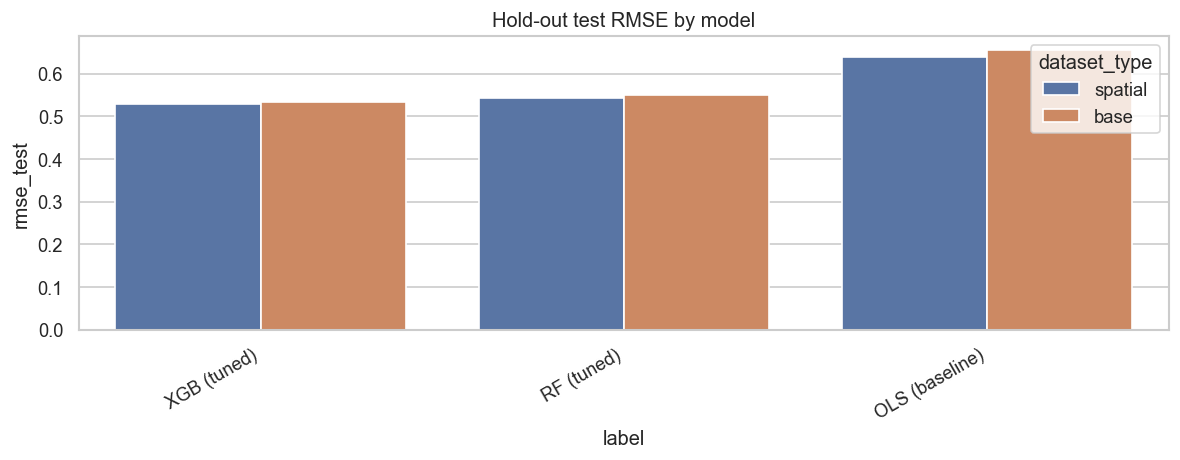

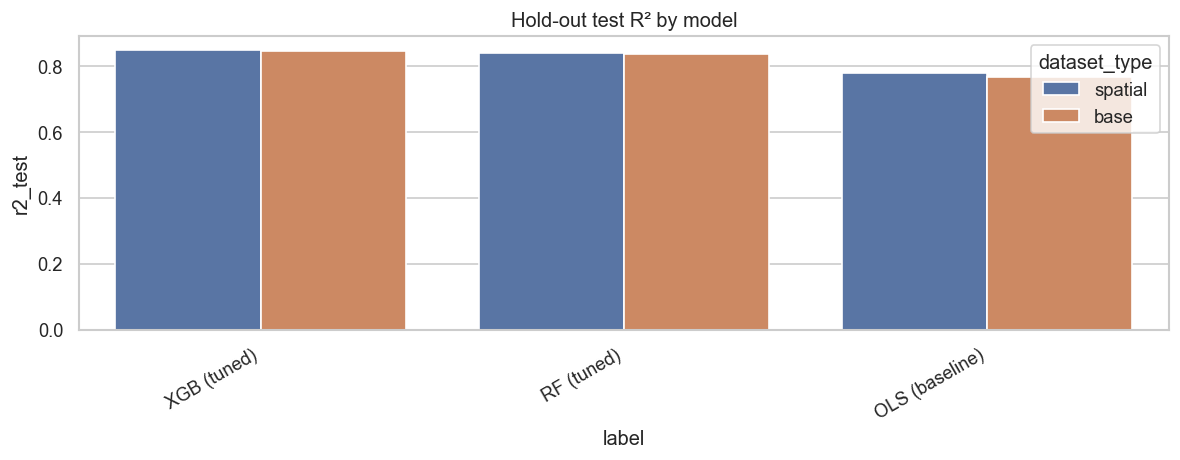

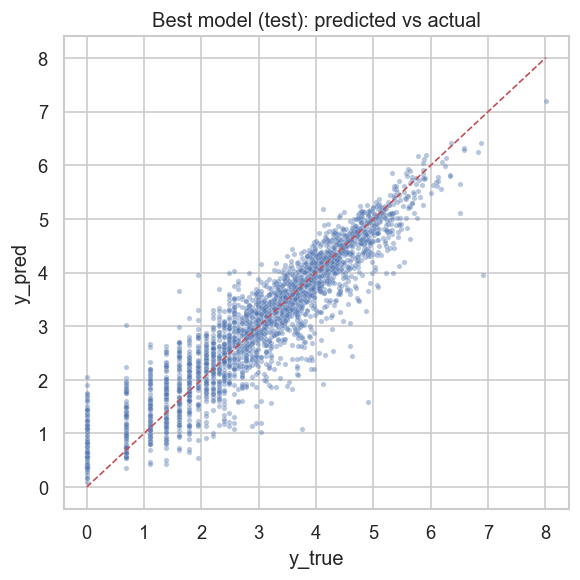

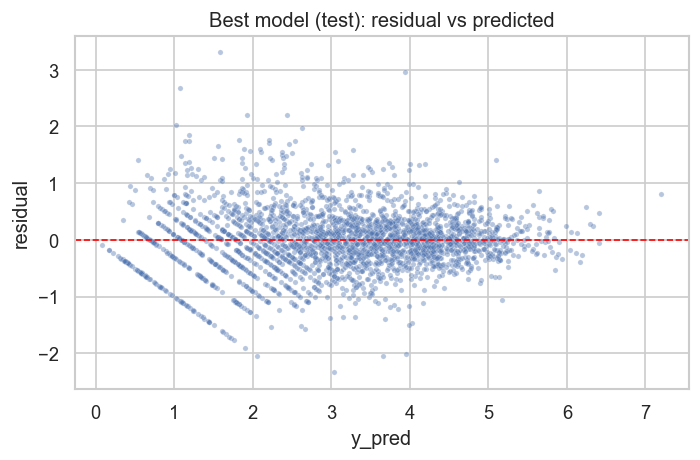

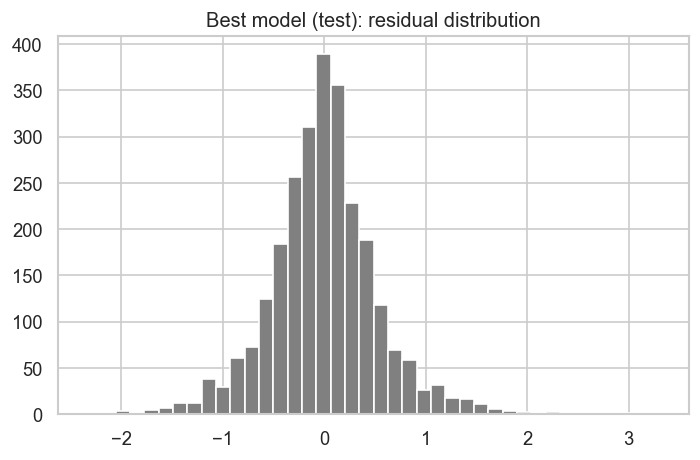

/var/folders/1l/q5ftm2z17hx00h6p9y5vjql80000gn/T/ipykernel_62138/3730038825.py:186: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_s, feature_names=feature_names, show=False)


Saved SHAP summary plot to: outputs/modeling_improvement/figures/shap_summary_best_xgb.png
Saved SHAP mean abs table to: outputs/modeling_improvement/shap_mean_abs_importance_best_xgb.csv


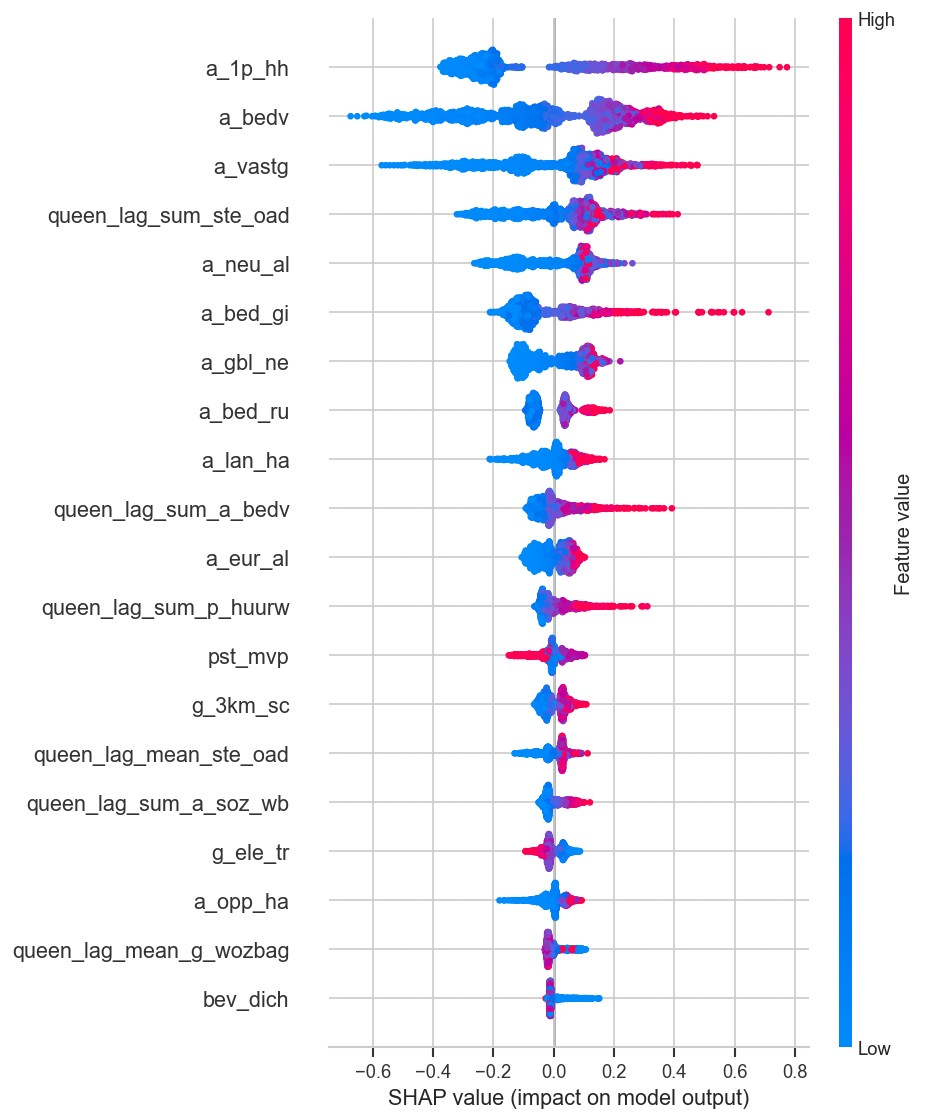

In [145]:
# ------------------------------------------------------------
# Final hold-out test set evaluation + thesis reporting outputs
# ------------------------------------------------------------
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

TEST_RESULTS_PATH = OUT_DIR / "final_test_set_results.csv"
TEST_PRED_PATH = OUT_DIR / "test_set_predictions_all_models.csv"

# Load test split that was created at the start of notebook 5
base_test_df = pd.read_csv(BASE_TEST_PATH, low_memory=False)
spatial_test_df = pd.read_csv(SPATIAL_TEST_PATH, low_memory=False)

print("\nLoaded test splits:")
print("- base_test_df:", base_test_df.shape)
print("- spatial_test_df:", spatial_test_df.shape)

# Build X/y for train and test using the same feature-selection logic
X_base_train, y_base_train, info_base_train = select_numeric_predictors(base_df, TARGET_COL, ID_COLS_BASE)
X_spatial_train, y_spatial_train, info_spatial_train = select_numeric_predictors(spatial_df, TARGET_COL, ID_COLS_SPATIAL)

X_base_test, y_base_test, _ = select_numeric_predictors(base_test_df, TARGET_COL, ID_COLS_BASE)
X_spatial_test, y_spatial_test, _ = select_numeric_predictors(spatial_test_df, TARGET_COL, ID_COLS_SPATIAL)

# Align columns explicitly (train defines the feature space)
X_base_test = X_base_test.reindex(columns=X_base_train.columns, fill_value=np.nan)
X_spatial_test = X_spatial_test.reindex(columns=X_spatial_train.columns, fill_value=np.nan)

print("\nFeature counts (train):")
print("- base:", X_base_train.shape[1])
print("- spatial:", X_spatial_train.shape[1])

# Helper to fit on full train and evaluate on test

def fit_predict_eval(model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    rmse = float(np.sqrt(mean_squared_error(yte, pred)))
    mae = float(mean_absolute_error(yte, pred))
    r2 = float(r2_score(yte, pred))
    return pred, rmse, mae, r2

results = []
preds = []

# Context cols (optional) for richer test diagnostics
ctx_cols = [c for c in ["gwb_code_10", "gm_naam", "population", "crime_count"] if c in base_test_df.columns]
ctx_base_test = base_test_df[ctx_cols].copy() if ctx_cols else pd.DataFrame(index=base_test_df.index)
ctx_spatial_test = spatial_test_df[ctx_cols].copy() if ctx_cols else pd.DataFrame(index=spatial_test_df.index)

# OLS (baseline)
for dataset_type, (Xtr, ytr, Xte, yte, ctx) in {
    "base": (X_base_train, y_base_train, X_base_test, y_base_test, ctx_base_test),
    "spatial": (X_spatial_train, y_spatial_train, X_spatial_test, y_spatial_test, ctx_spatial_test),
}.items():
    pred, rmse, mae, r2 = fit_predict_eval(pipe_ols(), Xtr, ytr, Xte, yte)
    results.append({"model": "OLS", "dataset_type": dataset_type, "tuning_status": "baseline", "rmse_test": rmse, "mae_test": mae, "r2_test": r2})
    dfp = ctx.copy()
    dfp["dataset_type"] = dataset_type
    dfp["model"] = "OLS"
    dfp["tuning_status"] = "baseline"
    dfp["y_true"] = yte.values
    dfp["y_pred"] = pred
    dfp["residual"] = dfp["y_true"] - dfp["y_pred"]
    dfp["abs_error"] = dfp["residual"].abs()
    preds.append(dfp)

# RF tuned
pred, rmse, mae, r2 = fit_predict_eval(rf_best_base, X_base_train, y_base_train, X_base_test, y_base_test)
results.append({"model": "RF", "dataset_type": "base", "tuning_status": "tuned", "rmse_test": rmse, "mae_test": mae, "r2_test": r2})
dfp = ctx_base_test.copy(); dfp["dataset_type"]="base"; dfp["model"]="RF"; dfp["tuning_status"]="tuned"; dfp["y_true"]=y_base_test.values; dfp["y_pred"]=pred; dfp["residual"]=dfp["y_true"]-dfp["y_pred"]; dfp["abs_error"]=dfp["residual"].abs(); preds.append(dfp)

pred, rmse, mae, r2 = fit_predict_eval(rf_best_spatial, X_spatial_train, y_spatial_train, X_spatial_test, y_spatial_test)
results.append({"model": "RF", "dataset_type": "spatial", "tuning_status": "tuned", "rmse_test": rmse, "mae_test": mae, "r2_test": r2})
dfp = ctx_spatial_test.copy(); dfp["dataset_type"]="spatial"; dfp["model"]="RF"; dfp["tuning_status"]="tuned"; dfp["y_true"]=y_spatial_test.values; dfp["y_pred"]=pred; dfp["residual"]=dfp["y_true"]-dfp["y_pred"]; dfp["abs_error"]=dfp["residual"].abs(); preds.append(dfp)

# XGB tuned
pred, rmse, mae, r2 = fit_predict_eval(xgb_best_base, X_base_train, y_base_train, X_base_test, y_base_test)
results.append({"model": "XGB", "dataset_type": "base", "tuning_status": "tuned", "rmse_test": rmse, "mae_test": mae, "r2_test": r2})
dfp = ctx_base_test.copy(); dfp["dataset_type"]="base"; dfp["model"]="XGB"; dfp["tuning_status"]="tuned"; dfp["y_true"]=y_base_test.values; dfp["y_pred"]=pred; dfp["residual"]=dfp["y_true"]-dfp["y_pred"]; dfp["abs_error"]=dfp["residual"].abs(); preds.append(dfp)

pred, rmse, mae, r2 = fit_predict_eval(xgb_best_spatial, X_spatial_train, y_spatial_train, X_spatial_test, y_spatial_test)
results.append({"model": "XGB", "dataset_type": "spatial", "tuning_status": "tuned", "rmse_test": rmse, "mae_test": mae, "r2_test": r2})
dfp = ctx_spatial_test.copy(); dfp["dataset_type"]="spatial"; dfp["model"]="XGB"; dfp["tuning_status"]="tuned"; dfp["y_true"]=y_spatial_test.values; dfp["y_pred"]=pred; dfp["residual"]=dfp["y_true"]-dfp["y_pred"]; dfp["abs_error"]=dfp["residual"].abs(); preds.append(dfp)

final_test = pd.DataFrame(results).sort_values(["rmse_test", "model", "dataset_type"]).reset_index(drop=True)
final_test.to_csv(TEST_RESULTS_PATH, index=False)

test_preds_all = pd.concat(preds, ignore_index=True)
test_preds_all.to_csv(TEST_PRED_PATH, index=False)

print("\nSaved hold-out test set results to:", TEST_RESULTS_PATH)
print("Saved hold-out test predictions to:", TEST_PRED_PATH)
print("\n=== Hold-out test set performance (RMSE / MAE / R²) ===")
print(final_test.to_string(index=False))

# -----------------
# Test-set figures
# -----------------
plt.figure(figsize=(10,4))
plot_df = final_test.copy()
plot_df['label'] = plot_df['model'] + ' (' + plot_df['tuning_status'] + ')'
sns.barplot(data=plot_df, x='label', y='rmse_test', hue='dataset_type', errorbar=None)
plt.title('Hold-out test RMSE by model')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'test_model_comparison_rmse.png')
plt.show()

plt.figure(figsize=(10,4))
sns.barplot(data=plot_df, x='label', y='r2_test', hue='dataset_type', errorbar=None)
plt.title('Hold-out test R² by model')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'test_model_comparison_r2.png')
plt.show()

# Best model on test (based on CV selection, then evaluated once on test)
best_test = test_preds_all[(test_preds_all['model']==BEST_MODEL) & (test_preds_all['dataset_type']==BEST_DATASET) & (test_preds_all['tuning_status']==BEST_TUNING)].copy()

plt.figure(figsize=(5,5))
sns.scatterplot(x=best_test['y_true'], y=best_test['y_pred'], s=10, alpha=0.4)
mn = min(best_test['y_true'].min(), best_test['y_pred'].min())
mx = max(best_test['y_true'].max(), best_test['y_pred'].max())
plt.plot([mn,mx],[mn,mx],'r--',lw=1)
plt.title('Best model (test): predicted vs actual')
plt.tight_layout()
plt.savefig(FIG_DIR / 'test_best_pred_vs_actual.png')
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x=best_test['y_pred'], y=best_test['residual'], s=10, alpha=0.4)
plt.axhline(0, color='red', ls='--', lw=1)
plt.title('Best model (test): residual vs predicted')
plt.tight_layout()
plt.savefig(FIG_DIR / 'test_best_residual_vs_pred.png')
plt.show()

plt.figure(figsize=(6,4))
plt.hist(best_test['residual'], bins=40, color='gray', edgecolor='white')
plt.title('Best model (test): residual distribution')
plt.tight_layout()
plt.savefig(FIG_DIR / 'test_best_residual_hist.png')
plt.show()

# -----------------
# SHAP on test set
# -----------------
if BEST_MODEL == 'XGB' and BEST_TUNING == 'tuned':
    try:
        import shap  # type: ignore
    except Exception:
        import sys
        import subprocess
        print('Installing shap...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap'])
        import shap  # type: ignore

    best_pipe = xgb_best_spatial if BEST_DATASET == 'spatial' else xgb_best_base
    Xtr = X_spatial_train if BEST_DATASET == 'spatial' else X_base_train
    ytr = y_spatial_train if BEST_DATASET == 'spatial' else y_base_train
    Xte = X_spatial_test if BEST_DATASET == 'spatial' else X_base_test

    best_pipe_full = Pipeline(steps=best_pipe.steps)
    best_pipe_full.fit(Xtr, ytr)

    imputer = best_pipe_full.named_steps.get('imputer')
    model = best_pipe_full.named_steps.get('model')

    if imputer is None or model is None:
        raise ValueError('Expected Pipeline with steps: imputer, model')

    X_imp = imputer.transform(Xte)
    feature_names = list(Xte.columns)

    rng = np.random.RandomState(RANDOM_STATE)
    n = X_imp.shape[0]
    sample_n = min(2000, n)
    idx = rng.choice(n, size=sample_n, replace=False)
    X_s = X_imp[idx]

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_s)

    shap_fig_path = FIG_DIR / 'shap_summary_best_xgb.png'
    plt.figure(figsize=(8, 5))
    shap.summary_plot(shap_values, X_s, feature_names=feature_names, show=False)
    plt.tight_layout()
    plt.savefig(shap_fig_path, dpi=200)

    # Mean absolute SHAP table
    mean_abs = np.abs(shap_values).mean(axis=0)
    shap_df = pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs}).sort_values("mean_abs_shap", ascending=False)
    shap_df.to_csv(OUT_DIR / 'shap_mean_abs_importance_best_xgb.csv', index=False)
    print('Saved SHAP summary plot to:', shap_fig_path)
    print('Saved SHAP mean abs table to:', OUT_DIR / 'shap_mean_abs_importance_best_xgb.csv')


## Methods (thesis-ready summary)

We evaluated a linear regression baseline and two tree-based regressors (random forest and XGBoost) using two feature sets: a non-spatial baseline dataset and a spatially-augmented dataset including exogenous queen-contiguity spillover features. To prevent geographic leakage, we created a municipality-grouped held-out test set by assigning approximately 20% of municipalities to the test set (`random_state=42`) and using the remaining municipalities as the training set. Model selection and hyperparameter tuning were performed on the training set only using 5-fold municipality-grouped cross-validation (`GroupKFold`). We used `RandomizedSearchCV` to tune RF and XGBoost with negative RMSE as the primary objective. All preprocessing with leakage risk (median imputation; scaling for linear regression) was implemented inside scikit-learn pipelines and fit on training folds only. After selecting configurations, we refit each model on the full training set and report final RMSE, MAE and R² on the held-out test set.
